# Statistical rigour: permutation null, bootstrap CIs, operating curve

Three additions an examiner in the seizure-prediction field will look for, all
computed on the flagship PDC VAR(20) features:

1. **Permutation (surrogate) null test** - the field standard (Mormann 2007;
   Schelter 2006) for proving performance exceeds chance. Labels are shuffled
   within each held-out patient and the metric recomputed many times to build a
   null distribution; the observed value's position gives an empirical p.
2. **Bootstrap confidence intervals** - resampling the 21 patients to put a 95%
   CI around the headline AUC / AUC-PR / Skill (the per-patient spread is large,
   so the CI matters).
3. **Operating curve** - event sensitivity vs false-alarms/hour across alarm
   thresholds, compared against Mormann's analytic random-predictor, so the
   operational claim is a curve rather than a single point.

Self-contained; reads `cache_pdc_var20/` and the verified metrics layer.


In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

import os, sys, warnings, time
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

# [path set by bootstrap] CODE   = Path(r"<repo>/Code")
# [path set by bootstrap] CODEV2 = Path(r"<repo>/this repository")
CACHE  = CODE/"cache_pdc_var20"; OUT=CODEV2/"outputs"; OUT.mkdir(exist_ok=True)
# sys.path.insert(0, str(CODEV2/"src"))
from seizure_metrics import generate_alarms, event_sensitivity, false_alarms_per_hour, infer_seizure_groups
from seeds import set_global_seed
set_global_seed(42); SEED=42
STEP_SEC=10; K,M,REFR=5,12,180; CAP_MULT,CAP_ABS=5,5000
EXCLUDED={"chb11","chb12","chb21"}
patients=sorted(p.name for p in CACHE.iterdir() if p.is_dir() and p.name.startswith("chb") and p.name not in EXCLUDED)
DATA={p:(np.load(CACHE/p/"features.npy").astype(np.float32), np.load(CACHE/p/"labels.npy").astype(int)) for p in patients}
def cap_balance(X,y,seed):
    r=np.random.default_rng(seed); npre=int((y==1).sum()); ii=np.where(y==0)[0]
    keep=min(len(ii),CAP_MULT*npre,CAP_ABS); sel=np.sort(np.concatenate([np.where(y==1)[0],r.choice(ii,keep,replace=False)])); return X[sel],y[sel]
def mk(name):
    c=LogisticRegression(max_iter=400,class_weight="balanced",C=0.1,random_state=SEED) if name=="LR" else SVC(kernel="rbf",C=0.1,class_weight="balanced",probability=False,random_state=SEED)
    return Pipeline([("s",StandardScaler()),("c",c)])
def scores(m,X):
    c=m.named_steps["c"]
    if hasattr(c,"predict_proba") and getattr(c,"probability",True): return m.predict_proba(X)[:,1]
    return 1/(1+np.exp(-m.decision_function(X)))
def run_lopo(name, sub=None):
    store={}
    for i,test in enumerate(patients):
        Xtr,ytr=[],[]
        for p in patients:
            if p==test: continue
            Xc,yc=cap_balance(*DATA[p],SEED+i); Xtr.append(Xc); ytr.append(yc)
        Xtr=np.vstack(Xtr); ytr=np.concatenate(ytr)
        if sub and len(ytr)>sub:
            r=np.random.default_rng(SEED+i); idx=r.choice(len(ytr),sub,replace=False); Xtr,ytr=Xtr[idx],ytr[idx]
        m=mk(name).fit(Xtr,ytr); X,y=DATA[test]
        store[test]=(scores(m,X), y)
    return store
print(len(patients),"patients")
t0=time.time(); STORE={"LR":run_lopo("LR"), "SVM":run_lopo("SVM",sub=12000)}
print("LOPO scored in %.0fs"%(time.time()-t0))


21 patients
LOPO scored in 684s


## 1 - Permutation (surrogate) null test
For each classifier: the observed mean AUC-PR (and AUC) across patients is
compared to a null built by shuffling each held-out patient's labels 2000 times
(prevalence preserved). p = fraction of null means >= observed.

In [2]:
def perm_test(store, n_perm=1000, metric="ap"):
    fn = average_precision_score if metric=="ap" else roc_auc_score
    obs=[]; per_patient_labels={}
    for pid,(pr,y) in store.items():
        if len(np.unique(y))<2: continue
        obs.append(fn(y,pr)); per_patient_labels[pid]=(pr,y)
    obs_mean=np.mean(obs)
    rng=np.random.default_rng(SEED); null=np.empty(n_perm)
    for b in range(n_perm):
        vals=[]
        for pid,(pr,y) in per_patient_labels.items():
            yp=rng.permutation(y); vals.append(fn(yp,pr))
        null[b]=np.mean(vals)
    p=(np.sum(null>=obs_mean)+1)/(n_perm+1)
    return obs_mean, null.mean(), null.std(), p

rows=[]
for nm in ["LR","SVM"]:
    for metric in ["ap","auc"]:
        o,nmean,nstd,p=perm_test(STORE[nm],metric=metric)
        rows.append({"model":nm,"metric":"AUC-PR" if metric=="ap" else "AUC","observed":round(o,3),
                     "null_mean":round(nmean,3),"null_sd":round(nstd,3),"p_perm":p})
perm=pd.DataFrame(rows); perm.to_csv(OUT/"stats_permutation.csv",index=False)
print(perm.to_string(index=False))
print("\n(p_perm < 0.05 => observed exceeds the label-shuffled null, i.e. genuinely above chance)")


model metric  observed  null_mean  null_sd   p_perm
   LR AUC-PR     0.382       0.34    0.003 0.000999
   LR    AUC     0.550       0.50    0.004 0.000999
  SVM AUC-PR     0.385       0.34    0.003 0.000999
  SVM    AUC     0.557       0.50    0.004 0.000999

(p_perm < 0.05 => observed exceeds the label-shuffled null, i.e. genuinely above chance)


## 2 - Bootstrap 95% confidence intervals
Resample the 21 patients with replacement (5000x) and recompute the mean of
each metric; report the 2.5/97.5 percentiles. Skill uses per-patient prevalence.

In [3]:
def boot_ci(store, n_boot=5000):
    pae=[]  # (auc, ap, skill) per patient
    for pid,(pr,y) in store.items():
        if len(np.unique(y))<2: continue
        prev=float((y==1).mean()); ap=average_precision_score(y,pr)
        pae.append((roc_auc_score(y,pr), ap, (ap-prev)/(1-prev)))
    A=np.array(pae); rng=np.random.default_rng(SEED); n=len(A)
    out={}
    for j,lab in enumerate(["AUC","AUC-PR","Skill"]):
        means=[A[rng.integers(0,n,n),j].mean() for _ in range(n_boot)]
        out[lab]=(round(A[:,j].mean(),3), round(np.percentile(means,2.5),3), round(np.percentile(means,97.5),3))
    return out
rows=[]
for nm in ["LR","SVM"]:
    ci=boot_ci(STORE[nm])
    for lab,(m,lo,hi) in ci.items():
        rows.append({"model":nm,"metric":lab,"mean":m,"CI95_low":lo,"CI95_high":hi})
boot=pd.DataFrame(rows); boot.to_csv(OUT/"stats_bootstrap_ci.csv",index=False)
print(boot.to_string(index=False))


model metric  mean  CI95_low  CI95_high
   LR    AUC 0.550     0.506      0.595
   LR AUC-PR 0.382     0.316      0.450
   LR  Skill 0.073     0.023      0.126
  SVM    AUC 0.557     0.509      0.604
  SVM AUC-PR 0.385     0.319      0.450
  SVM  Skill 0.074     0.020      0.131


## 3 - Operating curve: event sensitivity vs false alarms/hour
Sweeping the alarm threshold traces the achievable (FPR/h, sensitivity) points,
pooled across patients. The dashed line is Mormann's analytic random predictor:
for a Poisson alarm process at rate f, chance sensitivity in a preictal window of
length T is 1 - exp(-f*T). Points above the line beat chance.

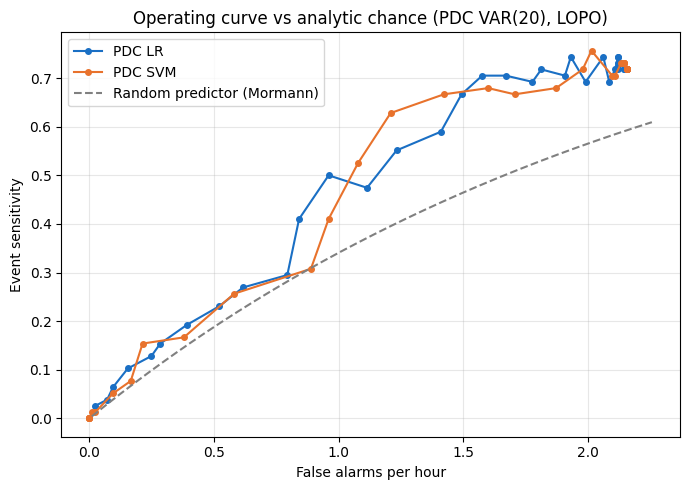

saved stats_operating_curve.png + per-model CSVs


In [4]:
def operating_points(store, thresholds=np.linspace(0.05,0.95,37)):
    T_h = (30-5)/60.0  # effective preictal window (25 min) in hours
    pts=[]
    for t in thresholds:
        hit=0; nseiz=0; falses=0; inter_h=0.0
        for pid,(pr,y) in store.items():
            groups=infer_seizure_groups(y)
            al=generate_alarms(pr,t,K,M,REFR)
            nseiz+=len(groups); hit+=sum(1 for g in groups if al[np.array(list(g))].any())
            falses+=int(((al==1)&(y==0)).sum()); inter_h+=float((y==0).sum())*STEP_SEC/3600
        sens=hit/max(nseiz,1); fph=falses/max(inter_h,1e-9)
        pts.append((fph,sens))
    return np.array(pts), T_h
fig,ax=plt.subplots(figsize=(7,5))
for nm,c in [("LR","#1a6fc4"),("SVM","#e8722c")]:
    pts,T_h=operating_points(STORE[nm]); pts=pts[np.argsort(pts[:,0])]
    ax.plot(pts[:,0],pts[:,1],"o-",color=c,label=f"PDC {nm}",ms=4)
    pd.DataFrame(pts,columns=["fpr_per_h","event_sensitivity"]).to_csv(OUT/f"stats_operating_{nm}.csv",index=False)
f=np.linspace(0.01,pts[:,0].max()+0.1,200); ax.plot(f,1-np.exp(-f*T_h),"--",color="gray",label="Random predictor (Mormann)")
ax.set_xlabel("False alarms per hour"); ax.set_ylabel("Event sensitivity"); ax.set_title("Operating curve vs analytic chance (PDC VAR(20), LOPO)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.savefig(OUT/"stats_operating_curve.png",dpi=140); plt.show()
print("saved stats_operating_curve.png + per-model CSVs")


## Summary for the write-up
- **Permutation test** tells you whether AUC / AUC-PR are genuinely above the
  label-shuffled null (report the p_perm values).
- **Bootstrap CIs** give the honest uncertainty on the headline numbers - quote
  e.g. "AUC-PR 0.40 (95% CI ...)".
- **Operating curve**: if the PDC points sit above the Mormann random-predictor
  line, the alarm system beats chance at matched FPR/h; if they hug it, that is
  itself the (honest) operational finding.
Paste the printed tables + the curve back and I will wire the numbers into the
Results/Discussion and Methodology.
